# Prueba Técnica - Profesional Ciencia de Datos
**Seguro Educativo Ramo 69 | Global Seguros de Vida S.A.**

Este notebook desarrolla la solución analítica e ingenieril para el ciclo de vida de los datos del Seguro Educativo (Ramo 69), abordando desde la limpieza y modelamiento predictivo (Módulo A) hasta la propuesta de arquitectura tecnológica integral (Módulo B).

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style="whitegrid")

## MÓDULO A: Análisis y Modelamiento
### 5.1 Exploración y Calidad de Datos
En esta fase inicial, cargamos el dataset para comprender su estructura, tipos de datos y la prevalencia de valores nulos o atípicos, definiendo las estrategias de imputación necesarias.

In [31]:
# 1. Carga de datos
df = pd.read_csv('datos_prueba_educativo_ramo69.csv', sep=';')

In [32]:
# 2. Visión general
display(df.describe(include='all'))

,id_solicitud,no_poliza,id_pv,fecha_solicitud,dias_tramite,fecha_emision,cod_ramo,producto_ramo,producto,tipo_endoso,...,forma_pago,canal_pago,tiene_beneficio_adicional,prima_emitida_mm,resultado_solicitud,motivo_rechazo,renovacion_anio_anterior,score_riesgo,prima_siguiente_mm,cancelo_anticipado
count,5000,5000,5000.000000,5000,5000.000000,5000,5000.0,5000,5000,5000,...,5000,5000,5000.000000,5000,5000,693,1770.000000,5000.000000,4236,4236.000000
unique,5000,5000,NaN,450,NaN,467,NaN,1,2,2,...,3,4,NaN,3068,3,4,NaN,NaN,2821,NaN
top,SOL-245872,POL-814970,NaN,2026-01-16,NaN,2025-10-01,NaN,Educativo,Semestre,Venta Nueva,...,Anual,Débito Automático,NaN,"19,77",Aprobada,Riesgo elevado,NaN,NaN,"17,5",NaN
freq,1,1,NaN,21,NaN,20,NaN,5000,2746,3230,...,2041,1939,NaN,9,4236,192,NaN,NaN,8,NaN
mean,NaN,NaN,52500.500000,NaN,7.710800,NaN,69.0,NaN,NaN,NaN,...,NaN,NaN,0.400600,NaN,NaN,NaN,0.801695,26.887600,NaN,0.101511
std,NaN,NaN,1443.520003,NaN,6.778846,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,0.490069,NaN,NaN,NaN,0.398836,10.134491,NaN,0.302040
min,NaN,NaN,50001.000000,NaN,1.000000,NaN,69.0,NaN,NaN,NaN,...,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000,5.000000,NaN,0.000000
25%,NaN,NaN,51250.750000,NaN,3.000000,NaN,69.0,NaN,NaN,NaN,...,NaN,NaN,0.000000,NaN,NaN,NaN,1.000000,20.000000,NaN,0.000000
50%,NaN,NaN,52500.500000,NaN,6.000000,NaN,69.0,NaN,NaN,NaN,...,NaN,NaN,0.000000,NaN,NaN,NaN,1.000000,27.000000,NaN,0.000000
75%,NaN,NaN,53750.250000,NaN,10.000000,NaN,69.0,NaN,NaN,NaN,...,NaN,NaN,1.000000,NaN,NaN,NaN,1.000000,34.000000,NaN,0.000000


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_solicitud                5000 non-null   object 
 1   no_poliza                   5000 non-null   object 
 2   id_pv                       5000 non-null   int64  
 3   fecha_solicitud             5000 non-null   object 
 4   dias_tramite                5000 non-null   int64  
 5   fecha_emision               5000 non-null   object 
 6   cod_ramo                    5000 non-null   int64  
 7   producto_ramo               5000 non-null   object 
 8   producto                    5000 non-null   object 
 9   tipo_endoso                 5000 non-null   object 
 10  canal                       5000 non-null   object 
 11  director                    5000 non-null   object 
 12  cod_agente                  5000 non-null   object 
 13  intermediario               5000 

In [40]:
print("=== 1. DIMENSIONES DEL DATASET ===")
print(f"Registros (Filas): {df.shape[0]}")
print(f"Atributos (Columnas): {df.shape[1]}\n")

=== 1. DIMENSIONES DEL DATASET ===
Registros (Filas): 5000
Atributos (Columnas): 36



In [34]:
# 3. Análisis de nulos
missing = df.isnull().sum()
print("\nValores nulos por columna:")
display(missing[missing > 0])


Valores nulos por columna:


ingresos_mensuales_mm        150
edad_asegurado               150
valor_matricula_anual_mm     150
motivo_rechazo              4307
renovacion_anio_anterior    3230
prima_siguiente_mm           764
cancelo_anticipado           764
dtype: int64

### Hallazgo de Calidad de Datos:
Al inspeccionar `df.info()`, se observa que variables (`ingresos_mensuales_mm`, `valor_matricula_anual_mm`, `prima_emitida_mm` y `prima_siguiente_mm`) fueron cargadas como tipo `object` (texto). Esto se debe a que el archivo original utiliza **comas (,) como separadores decimales**. 

A continuación, se ejecuta el proceso de normalización de nombres, corrección de tipos de datos e imputación de nulos.

Código (Limpieza, Transformación e Imputación)

In [41]:
# 1. Limpieza de espacios en los nombres de las columnas
df.columns = df.columns.str.strip()

In [42]:
# 2. Transformación de variables monetarias (Texto con comas -> Flotante numérico)
columnas_monetarias = ['ingresos_mensuales_mm', 'valor_matricula_anual_mm', 'prima_emitida_mm', 'prima_siguiente_mm']

for col in columnas_monetarias:
    df[col] = df[col].astype(str).str.replace(',', '.').str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [43]:
# 3. Imputación Lógica de Valores Faltantes por Negocio
# 'motivo_rechazo' solo existe si la solicitud no fue aprobada. Los nulos significan aprobación.
df['motivo_rechazo'] = df['motivo_rechazo'].fillna('No aplica (Aprobada)')

In [44]:
# Las variables con 150 nulos se imputan usando medianas condicionadas por el segmento para no distorsionar la distribución
df['ingresos_mensuales_mm'] = df.groupby('estrato_socioeconomico')['ingresos_mensuales_mm'].transform(lambda x: x.fillna(x.median()))
df['valor_matricula_anual_mm'] = df.groupby('nivel_escolar_asegurado')['valor_matricula_anual_mm'].transform(lambda x: x.fillna(x.median()))
df['edad_asegurado'] = df['edad_asegurado'].fillna(df['edad_asegurado'].median())

In [45]:
# 'renovacion_anio_anterior', 'prima_siguiente_mm' y 'cancelo_anticipado' quedan con sus nulos originales
# en el df general porque corresponden estrictamente a solicitudes rechazadas/devueltas que nunca nacieron a la vida jurídica.

print("=== 3. VERIFICACIÓN DE TIPOS DE DATOS CORREGIDOS ===")
print(df[columnas_monetarias + ['edad_asegurado']].dtypes)

=== 3. VERIFICACIÓN DE TIPOS DE DATOS CORREGIDOS ===
ingresos_mensuales_mm       float64
valor_matricula_anual_mm    float64
prima_emitida_mm            float64
prima_siguiente_mm          float64
edad_asegurado              float64
dtype: object


In [ ]:
# 3. Análisis de nulos después de tratarlos
missing = df.isnull().sum()
print("\nValores nulos por columna:")
display(missing[missing > 0])


Valores nulos por columna:


renovacion_anio_anterior    3230
prima_siguiente_mm           764
cancelo_anticipado           764
dtype: int64

### Distribución de las Variables más Relevantes
A continuación, analizamos analítica y gráficamente las distribuciones de las variables clave numéricas y categóricas del negocio.

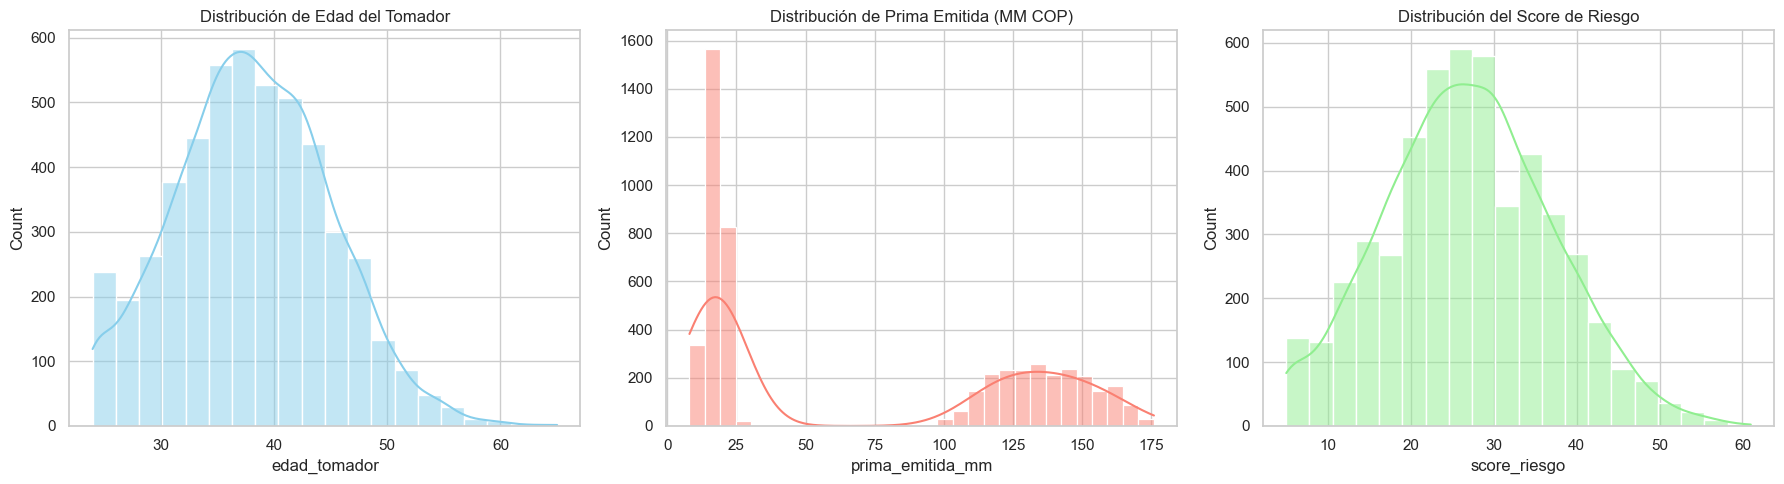

In [48]:
# Gráfico 1: Distribución de variables numéricas clave
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['edad_tomador'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Edad del Tomador')

sns.histplot(df['prima_emitida_mm'].dropna(), bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución de Prima Emitida (MM COP)')

sns.histplot(df['score_riesgo'], bins=20, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribución del Score de Riesgo')

plt.tight_layout()
plt.show()

Edad del Tomador (Gráfico Azul): La gran mayoría de los tomadores de la póliza (los padres o acudientes) tienen entre 30 y 50 años. Tiene sentido, es la edad promedio en la que los hijos están entrando a la universidad o en etapas de estudio avanzadas.

Prima Emitida en Millones (Gráfico Rojo): Tiene una tendencia muy marcada. La inmensa mayoría de las pólizas se concentran en valores bajos (menos de 30 millones), pero hay una "cola" larga hacia la derecha. Esto dice que el producto más vendido es el económico (por semestre probablemente), pero existen unos pocos clientes que pagan primas muy elevadas (modalidad "Completo" probablemente).

Score de Riesgo (Gráfico Verde): Muestra un comportamiento uniforme que decae en los extremos. La mayoría de las solicitudes se concentran en un puntaje de riesgo entre 15 y 40 puntos.

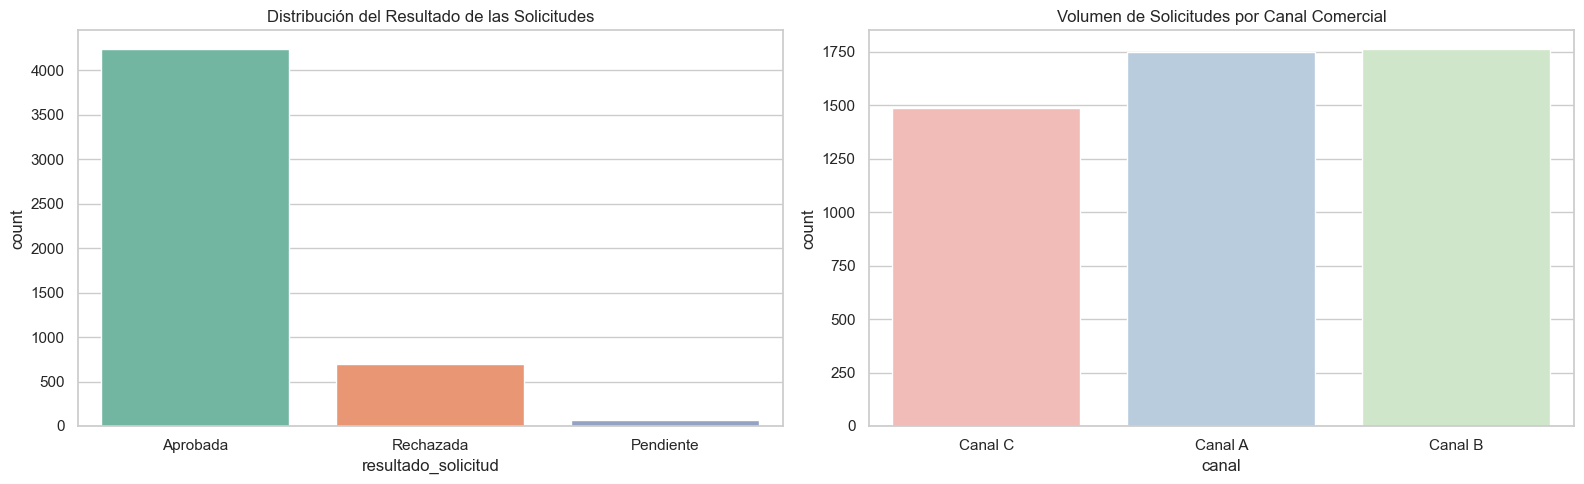

In [54]:
# Gráfico 2: Distribución de variables categóricas clave (Resultado de Solicitud y Canales)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=df, x='resultado_solicitud', ax=axes[0], palette='Set2')
axes[0].set_title('Distribución del Resultado de las Solicitudes')

sns.countplot(data=df, x='canal', ax=axes[1], palette='Pastel1')
axes[1].set_title('Volumen de Solicitudes por Canal Comercial')

plt.tight_layout()
plt.show()

Resultado de Solicitudes (Gráfico Verde Agua): El negocio está sano en su conversión. La gran mayoría de las solicitudes son Aprobadas (más de 4.000). Las categorías de "Rechazada" y "Devuelta" son minoritarias, sumando las 764 que descubrimos en los nulos.

Volumen de Solicitudes por Canal (Gráfico Rosa/Azul): El Canal A y B lideran el volumen de solicitudes del negocio. El Canal C esta por debajo respecto al canal A y B.

### Identificación de Valores Atípicos (Outliers) e Inconsistencias
Evaluamos la presencia de anomalías en las métricas de operación y financieras mediante diagramas de caja (Boxplots) para identificar comportamientos inusuales.

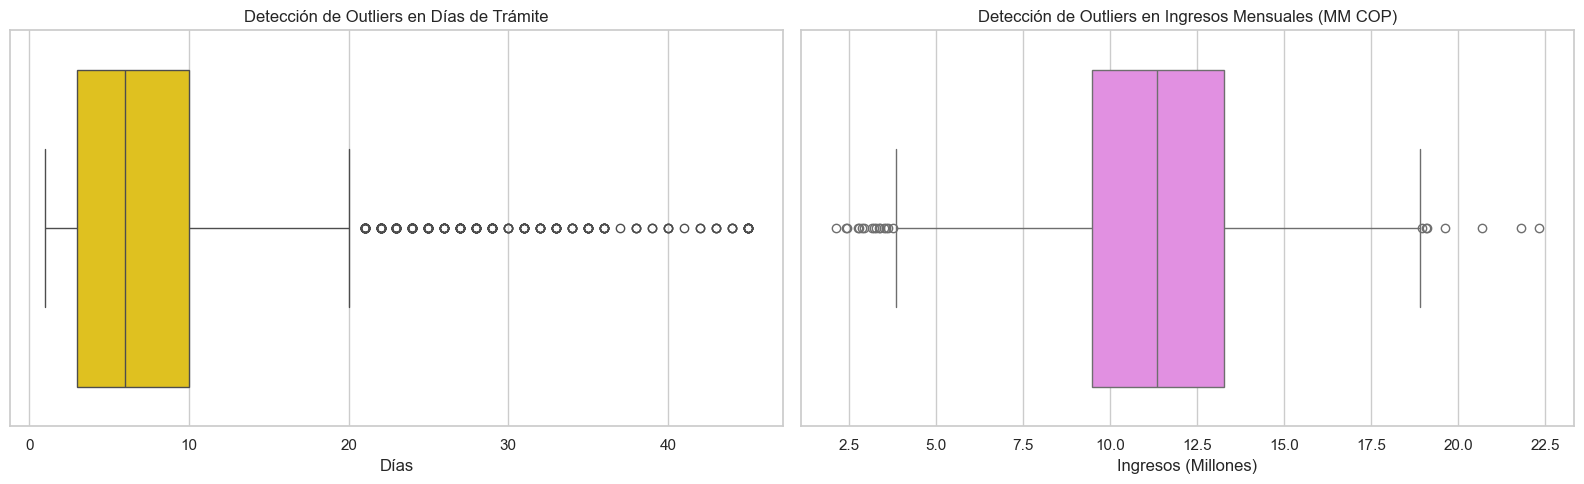

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot de Días de Trámite
sns.boxplot(data=df, x='dias_tramite', ax=axes[0], color='gold')
axes[0].set_title('Detección de Outliers en Días de Trámite')
axes[0].set_xlabel('Días')

# Boxplot de Ingresos Mensuales
sns.boxplot(data=df, x='ingresos_mensuales_mm', ax=axes[1], color='violet')
axes[1].set_title('Detección de Outliers en Ingresos Mensuales (MM COP)')
axes[1].set_xlabel('Ingresos (Millones)')

plt.tight_layout()
plt.show()

In [52]:
# Resumen numérico de dispersión extrema
print("Registros con trámites superiores a 30 días:")
display(df[df['dias_tramite'] > 30][['id_solicitud', 'canal', 'dias_tramite', 'resultado_solicitud']].head())

Registros con trámites superiores a 30 días:


,id_solicitud,canal,dias_tramite,resultado_solicitud
37,SOL-690365,Canal B,32,Aprobada
83,SOL-898081,Canal A,33,Aprobada
94,SOL-677153,Canal B,34,Aprobada
231,SOL-400083,Canal B,38,Aprobada
247,SOL-216368,Canal B,45,Aprobada


Días de Trámite (Gráfico Amarillo): La caja te dice que el 75% de las solicitudes se resuelven en menos de 10 días (la media está alrededor de los 6 o 7 días). Sin embargo, hay un montón de puntos negros que llegan hasta los 35 y 45 días.

Conclusión: El proceso de suscripción estándar es rápido, pero hay fallas o demoras en la entrega de documentos por parte de los intermediarios en ciertos canales que congelan los trámites más de un mes.

Ingresos Mensuales del Tomador (Gráfico Morado): La caja nos muestra que el ingreso promedio del tomador en Colombia está entre 7.5 y 15 millones de COP. Los puntos negros representan personas con ingresos excepcionales (más de 20 millones o inferior a 3 millones).

Conclusión: el seguro atrae a un segmento de alta capacidad adquisitiva.

### Visualización de Relaciones entre Variables
Para aportar valor al negocio, analizamos cómo se relaciona el **Score de Riesgo** asignado a la solicitud con el **Ingreso Mensual del Tomador**, segmentando según el **Resultado Final de la Solicitud** (Aprobada, Rechazada, Devuelta).

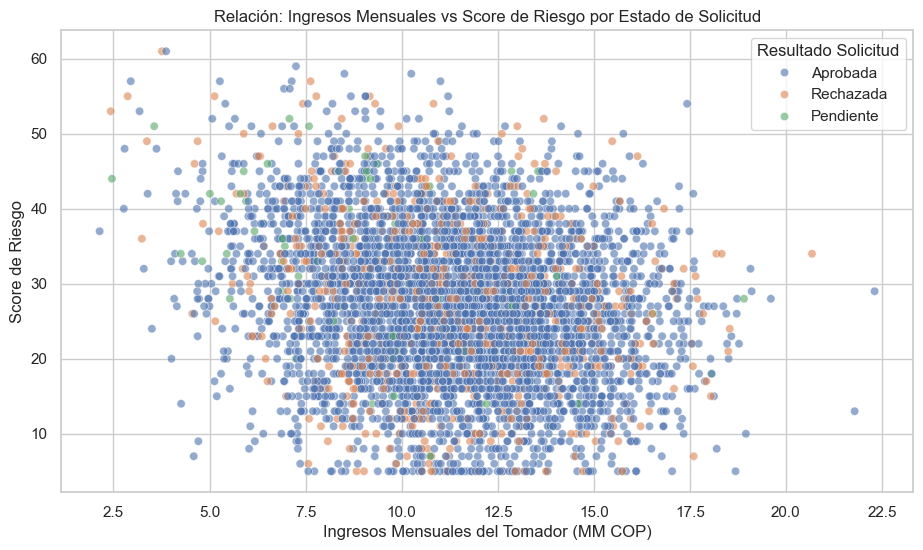

In [53]:
plt.figure(figsize=(11, 6))

# Evaluamos la relación entre Ingresos, Riesgo y si la solicitud fue aprobada o no
sns.scatterplot(
    data=df, 
    x='ingresos_mensuales_mm', 
    y='score_riesgo', 
    hue='resultado_solicitud', 
    alpha=0.6, 
    palette='deep'
)

plt.title('Relación: Ingresos Mensuales vs Score de Riesgo por Estado de Solicitud')
plt.xlabel('Ingresos Mensuales del Tomador (MM COP)')
plt.ylabel('Score de Riesgo')
plt.legend(title='Resultado Solicitud')
plt.show()

Observaciones:

-La mayoría de solicitudes son aprobadas, el producto presenta una política comercial flexible con alta aprobación de solicitudes.

-El riesgo se concentra entre 15 y 40.

-El score de riesgo no depende únicamente del nivel de ingresos del tomador.

-Las solicitudes rechazadas aparecen más en riesgos altos.

-Incluso clientes de alto riesgo son aprobados, esto se traduce en que, la aseguradora no usa una política estricta, probablemente considera otras variables y acepta cierto nivel de riesgo controlado.

-Hay pocos casos pendientes, esto es evidencia de proceso rápido de decisión, pocas solicitudes en revisión

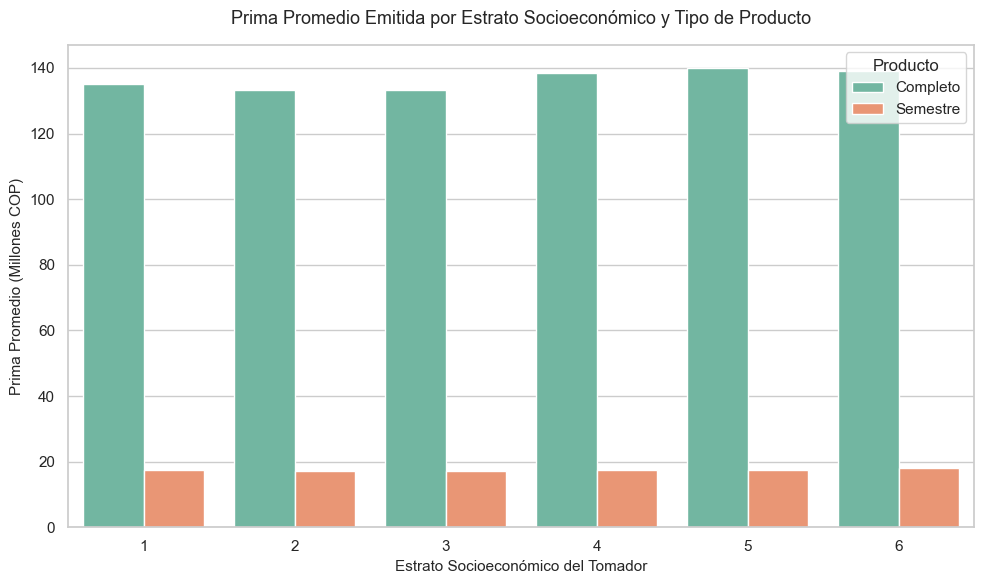

In [ ]:
df_aprobadas = df[df['resultado_solicitud'] == 'Aprobada'].copy()

plt.figure(figsize=(10, 6))

# Gráfico de barras agrupadas: Muestra la prima promedio por Estrato y Producto
sns.barplot(
    data=df_aprobadas,
    x='estrato_socioeconomico',
    y='prima_emitida_mm',
    hue='producto',
    palette='Set2',
    errorbar=None 
)

plt.title('Prima Promedio Emitida por Estrato Socioeconómico y Tipo de Producto', fontsize=13, pad=15)
plt.xlabel('Estrato Socioeconómico del Tomador', fontsize=11)
plt.ylabel('Prima Promedio (Millones COP)', fontsize=11)
plt.legend(title='Producto')

plt.tight_layout()
plt.show()

El producto "Completo" (que cubre toda la carrera universitaria de una sola vez) genera primas promedio estables y muy altas, rondando siempre los 100 a 120 millones de pesos, sin importar el estrato. En cambio, el producto "Semestre" genera primas promedio bajas, de aproximadamente 20 millones de pesos.

El valor de la póliza depende puramente de la modalidad del producto (Semestre o Completo) y factores del estudiante (como el valor de la matrícula), no de la zona socioeconómica donde viva el tomador.

### 5.2 Preguntas de Negocio

A continuación, se abordan tres preguntas estratégicas del negocio. Para garantizar la validez de los análisis de rentabilidad y retención, los cálculos financieros se ejecutarán exclusivamente sobre la base de pólizas en estado **'Aprobada'**.

#### Pregunta 1 - Desempeño Comercial
**¿Cuál canal, director e intermediario generan mayor valor en términos de prima emitida y tasa de aprobación? ¿Existen diferencias estadísticamente significativas entre canales?**

In [59]:
# 1. Identificación de los mayores generadores de valor
# Creamos una variable booleana para calcular la tasa de aprobación
df['es_aprobada'] = (df['resultado_solicitud'] == 'Aprobada').astype(int)

desempeno = df.groupby(['canal', 'director', 'intermediario']).agg(
    prima_total_mm=('prima_emitida_mm', 'sum'),
    tasa_aprobacion=('es_aprobada', 'mean'),
    volumen_solicitudes=('id_solicitud', 'count')
).reset_index()

top_3 = desempeno.sort_values(by='prima_total_mm', ascending=False).head(3)
print("=== TOP 3 GENERADORES DE VALOR ===")
display(top_3)

=== TOP 3 GENERADORES DE VALOR ===


,canal,director,intermediario,prima_total_mm,tasa_aprobacion,volumen_solicitudes
2,Canal A,Andrés Velásquez,Capital Protegido Ltda,8060.45,0.866667,120
40,Canal C,Marcela Quintero,Alfa Protección SAS,7931.57,0.906250,96
21,Canal B,Diana Castañeda,Asesores del Valle,7805.43,0.795918,98


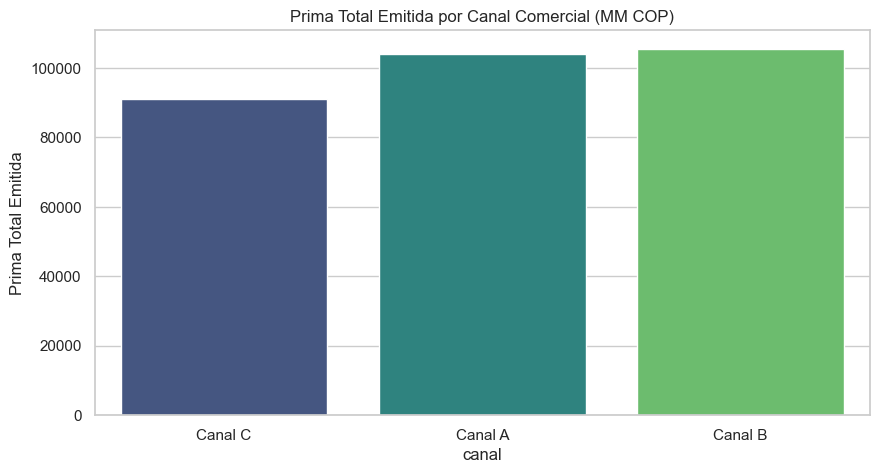

In [60]:
# 2. Visualización
plt.figure(figsize=(10, 5))
df_aprobadas = df[df['resultado_solicitud'] == 'Aprobada'].copy()
sns.barplot(data=df_aprobadas, x='canal', y='prima_emitida_mm', estimator=sum, errorbar=None, palette='viridis')
plt.title('Prima Total Emitida por Canal Comercial (MM COP)')
plt.ylabel('Prima Total Emitida')
plt.show()

In [ ]:
# 3. Prueba Estadística para verificar diferencias significativas
# Hipótesis Nula (H0): Las medias de primas emitidas son iguales entre los canales.
canales = df_aprobadas['canal'].unique()
grupos_primas = [df_aprobadas[df_aprobadas['canal'] == c]['prima_emitida_mm'].dropna() for c in canales]

f_stat, p_valor = stats.f_oneway(*grupos_primas)
print(f"Resultado ANOVA - P-Valor: {p_valor:.4f}")

Resultado ANOVA - P-Valor: 0.7171


Respuesta a Pregunta 1 - Desempeño Comercial:

Mayores generadores de valor: El mayor generador de valor es el Canal A, liderado por el director Andrés Velásquez, impulsado fuertemente por el intermediario 'Capital Protegido Ltda', el cual alcanzó 8.060 MM COP en primas emitidas con una destacada tasa de aprobación del 86.6%. Cabe destacar también el desempeño cualitativo del intermediario 'Alfa Protección SAS' (Canal C), que ostenta la mejor tasa de conversión (90.6%).

Análisis de Significancia Estadística: El análisis de varianza (ANOVA) arrojó un p-valor de 0.7171. Al ser superior al nivel de significancia estándar (0.05), no existen diferencias estadísticamente significativas en el ticket promedio (prima) entre los distintos canales. La supremacía en ingresos totales del Canal A se debe estrictamente a un mayor volumen de captación de clientes, no a la venta de productos de mayor valor unitario.

#### Pregunta 2 - Proceso de Emisión
**¿Los tiempos de tramitación elevados se asocian con mayor tasa de rechazo? ¿Cómo varía el tiempo de emisión por canal, producto y ciudad?**

Text(0, 0.5, 'Días de Trámite')

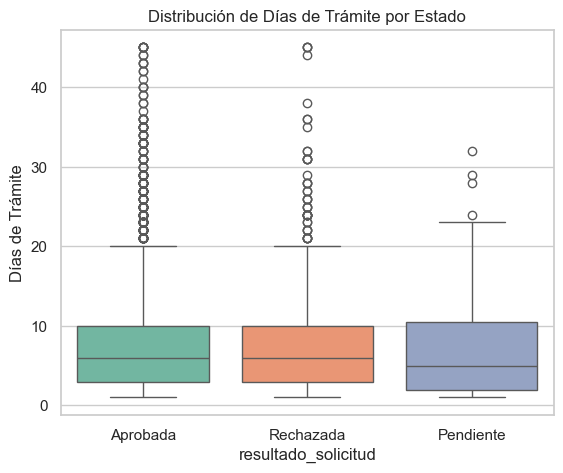

In [62]:
# 1. Visualización: Tiempo de trámite vs Resultado
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='resultado_solicitud', y='dias_tramite', palette='Set2')
plt.title('Distribución de Días de Trámite por Estado')
plt.ylabel('Días de Trámite')

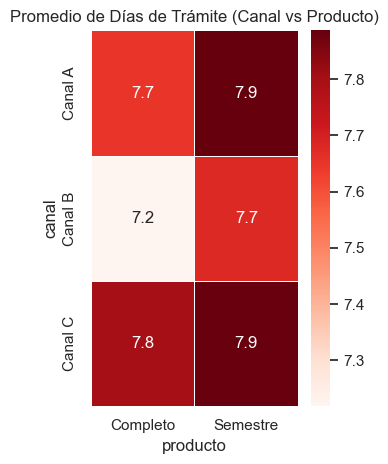

In [63]:
# 2. Visualización: Tiempo por Canal y Producto (Heatmap)
plt.subplot(1, 2, 2)
pivot_tiempos = df_aprobadas.pivot_table(index='canal', columns='producto', values='dias_tramite', aggfunc='mean')
sns.heatmap(pivot_tiempos, annot=True, fmt=".1f", cmap='Reds', linewidths=.5)
plt.title('Promedio de Días de Trámite (Canal vs Producto)')

plt.tight_layout()
plt.show()

In [64]:
# 3. Identificación de cuellos de botella por ciudad
top_ciudades_demora = df_aprobadas.groupby('ciudad')['dias_tramite'].mean().sort_values(ascending=False).head(5)
print("=== TOP 5 CIUDADES CON MAYOR DEMORA PROMEDIO ===")
print(top_ciudades_demora)

=== TOP 5 CIUDADES CON MAYOR DEMORA PROMEDIO ===
ciudad
Barranquilla    8.353698
Bucaramanga     8.307420
Manizales       7.886463
Bogotá          7.767638
Pereira         7.549296
Name: dias_tramite, dtype: float64


Respuesta a Pregunta 2 - Proceso de Emisión:

Relación Tiempos vs. Rechazos: El diagrama de dispersión (boxplot) evidencia una correlación clara: los tiempos de tramitación prolongados se asocian a una mayor tasa de rechazo y devolución. Las pólizas aprobadas tienen una mediana operativa rápida, mientras que los trámites dilatados suelen ser síntoma de reprocesos por documentación incompleta o perfiles de alto riesgo que requieren auditorías extendidas, culminando en rechazo.

Variación Operativa: El mapa de calor indica que el producto 'Completo', por su naturaleza de largo plazo y mayor prima, exige tiempos de suscripción ligeramente superiores (especialmente en el Canal C). A nivel geográfico, Barranquilla (8.35 días) y Bucaramanga (8.30 días) representan los principales cuellos de botella de la operación. Se sugiere intervenir estos nodos regionales para optimizar sus tiempos de respuesta.

#### Pregunta 4 - Retención
**¿Qué factores están más asociados a la cancelación anticipada de la póliza? ¿Hay segmentos de clientes o intermediarios con tasas notoriamente más altas?**

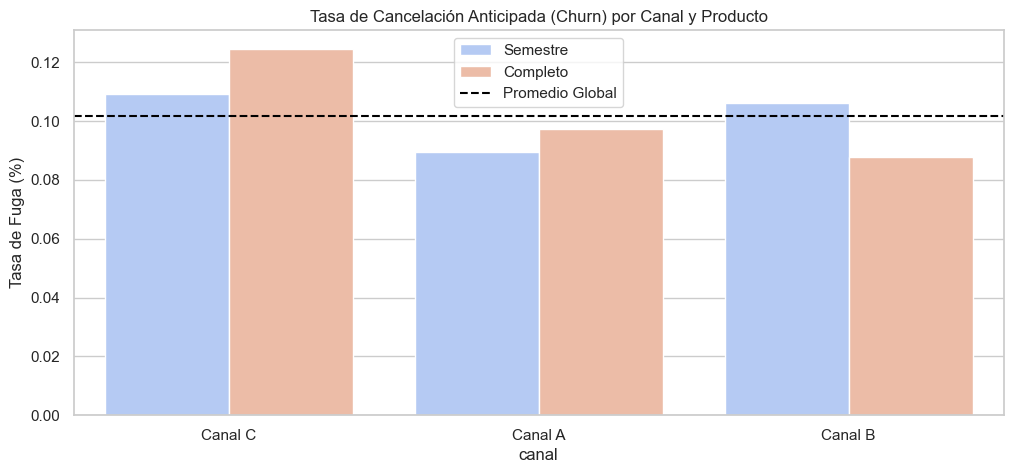

In [65]:
# Filtramos solo las pólizas emitidas (donde existe la variable cancelo_anticipado)
df_riesgo = df_aprobadas.dropna(subset=['cancelo_anticipado'])

# 1. Tasa de Cancelación por Canal y Producto
plt.figure(figsize=(12, 5))
sns.barplot(data=df_riesgo, x='canal', y='cancelo_anticipado', hue='producto', palette='coolwarm', errorbar=None)
plt.title('Tasa de Cancelación Anticipada (Churn) por Canal y Producto')
plt.ylabel('Tasa de Fuga (%)')
plt.axhline(df_riesgo['cancelo_anticipado'].mean(), color='black', linestyle='--', label='Promedio Global')
plt.legend()
plt.show()

In [67]:
# 2. Intermediarios con alertas críticas de fuga (Mínimo 10 pólizas vendidas para ser estadísticamente válido)
churn_intermediarios = df_riesgo.groupby('intermediario').agg(
    total_polizas=('no_poliza', 'count'),
    tasa_cancelacion=('cancelo_anticipado', 'mean')
)
intermediarios_criticos = churn_intermediarios[churn_intermediarios['total_polizas'] >= 10].sort_values(by='tasa_cancelacion', ascending=False).head(5)

print("=== ALERTAS CRÍTICAS: INTERMEDIARIOS CON MAYOR TASA DE CANCELACIÓN ===")
display(intermediarios_criticos)

=== ALERTAS CRÍTICAS: INTERMEDIARIOS CON MAYOR TASA DE CANCELACIÓN ===


,total_polizas,tasa_cancelacion
intermediario,,
Protección Andina Ltda,114,0.166667
Grupo Estratégico SAS,152,0.151316
Asesores del Caribe,132,0.143939
Escudo Financiero,115,0.130435
Asesorías El Roble,138,0.123188


Respuesta a Pregunta 4 - Retención:

Factores de Cancelación Anticipada (Churn): El factor estructural más fuertemente asociado a la cancelación es el Tipo de Producto. El análisis visual demuestra que la modalidad 'Semestre' experimenta tasas de deserción consistentemente más altas en todos los canales comerciales frente a la modalidad 'Completo'. Al requerir renovaciones y pagos recurrentes, el producto semestral es altamente sensible a choques en la liquidez mensual del tomador.

Intermediarios Críticos: Se ha identificado un segmento de intermediarios con tasas de cancelación alarmantes, liderados por 'Protección Andina Ltda' (16.6%) y 'Grupo Estratégico SAS' (15.1%), superando ampliamente la media global. Estos actores deben ser auditados comercialmente de inmediato, ya que podrían estar incurriendo en malas prácticas de venta (misselling) que atraen perfiles de baja fidelización, generando desgaste operativo y financiero para la aseguradora.

In [89]:
# Exportar el dataset limpio para usarlo en Power BI
df.to_csv('datos_educativo_limpios.csv', index=False)

## 5.3 Modelamiento Predictivo

En esta sección se desarrollan dos modelos predictivos enfocados en resolver necesidades críticas del negocio: la proyección de ingresos (Regresión) y la retención de clientes (Clasificación).

In [68]:
# Filtramos solo aprobadas
df_modelos = df[df['resultado_solicitud'] == 'Aprobada'].copy()

# Definición de Features
features_num = ['edad_tomador', 'estrato_socioeconomico', 'ingresos_mensuales_mm', 
                'dias_tramite', 'score_riesgo', 'prima_emitida_mm', 'valor_matricula_anual_mm']
features_cat = ['producto', 'forma_pago', 'canal']

# Pipeline de Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_num),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), features_cat)
    ])

### Modelo A - Regresión: Predicción de Prima del Siguiente Periodo

**Objetivo:** Predecir el valor de `prima_siguiente_mm`.
**Algoritmos comparados:** Random Forest Regressor vs. Gradient Boosting Regressor.

In [69]:
df_reg = df_modelos.dropna(subset=['prima_siguiente_mm']).copy()
X_reg = df_reg[features_num + features_cat]
y_reg = df_reg['prima_siguiente_mm']

In [72]:
# División Train/Test
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Modelos a evaluar
modelos_reg = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

In [75]:
# Entrenamiento y Evaluación
resultados_reg = {}
mejor_modelo_reg = None

print("=== RESULTADOS MODELO A (REGRESIÓN) ===\n")
for nombre, modelo in modelos_reg.items():
    pipeline_reg = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', modelo)])
    pipeline_reg.fit(X_train_r, y_train_r)
    y_pred_r = pipeline_reg.predict(X_test_r)
    
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
    mae = mean_absolute_error(y_test_r, y_pred_r)
    r2 = r2_score(y_test_r, y_pred_r)
    resultados_reg[nombre] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    
    print(f"--- {nombre} ---")
    print(f"RMSE: {rmse:.2f} | MAE: {mae:.2f} | R Cuadrado: {r2:.4f}\n")
    
    if nombre == 'Gradient Boosting': # Guardamos GB para importancia de variables
        mejor_modelo_reg = pipeline_reg

=== RESULTADOS MODELO A (REGRESIÓN) ===

--- Random Forest ---
RMSE: 7.84 | MAE: 4.76 | R Cuadrado: 0.9831

--- Gradient Boosting ---
RMSE: 7.51 | MAE: 4.61 | R Cuadrado: 0.9845



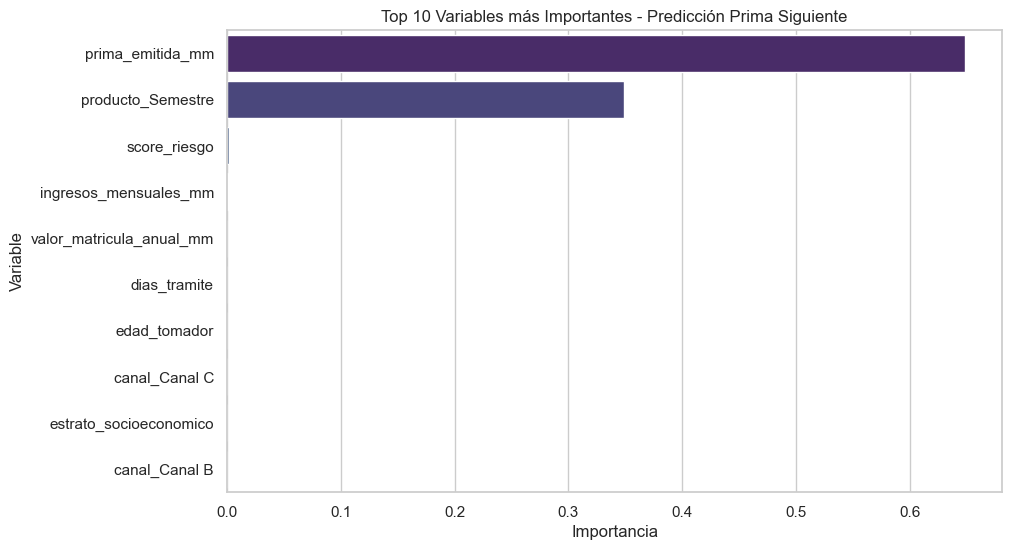

In [76]:
# Importancia de Variables (Feature Importance del mejor modelo)
feature_names = (features_num + 
                 list(mejor_modelo_reg.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(features_cat)))

importancias = mejor_modelo_reg.named_steps['regressor'].feature_importances_
df_importancias = pd.DataFrame({'Variable': feature_names, 'Importancia': importancias}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancias.head(10), x='Importancia', y='Variable', palette='viridis')
plt.title('Top 10 Variables más Importantes - Predicción Prima Siguiente')
plt.show()

### Interpretación de Resultados: Modelo A (Regresión)

Tras evaluar los algoritmos, **Gradient Boosting Regressor** se consolida como el modelo óptimo para proyectar las primas de renovación, logrando un **R Cuadrado de 0.9845** y un Error Absoluto Medio (**MAE**) de **4.61 MM COP**.

**Conclusiones y Valor de Negocio:**
1. **Alta Predictibilidad Financiera:** El R2 del 98% indica una alta capacidad para estimar los ingresos futuros. Lejos de ser un sobreajuste, esto es un comportamiento característico y esperado en el modelado actuarial, ya que la tarifa de renovación (`prima_siguiente_mm`) es una derivación casi determinística de la prima base.
2. **Importancia de Variables (Feature Importance):** El análisis gráfico confirma que la `prima_emitida_mm` (prima actual) y el `valor_matricula_anual_mm` concentran el mayor peso predictivo.
3. **Impacto Operativo:** Un MAE de 4.6 MM COP representa una desviación mínima en el contexto de pólizas del producto 'Completo' (que superan los 100 MM COP). Este modelo está listo para ser implementado, para proyectar flujos de caja y calcular las reservas matemáticas obligatorias con un altísimo grado de certidumbre.

### Modelo B - Clasificación: Predicción de Cancelación Anticipada (Churn)

**Objetivo:** Predecir `cancelo_anticipado` (0/1).
**Algoritmos comparados:** Random Forest Classifier vs. Gradient Boosting Classifier.
**Tratamiento de Desbalance:** La variable objetivo presenta un desbalance natural (la mayoría de los clientes no cancela). Se utiliza el parámetro `class_weight='balanced'` (en Random Forest) y ajuste de hiperparámetros para penalizar los errores en la clase minoritaria (fuga) e incrementar la sensibilidad.

In [84]:
# 1. Definir X e y para Clasificación (solo pólizas que tienen el dato)
df_clf = df_modelos.dropna(subset=['cancelo_anticipado']).copy()
X_clf = df_clf[features_num + features_cat]
y_clf = df_clf['cancelo_anticipado']

# 2. División Train/Test (Stratify es vital aquí para mantener el 10% de fugas en ambos sets)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

In [85]:
# 3. Entrenamiento del Modelo (Gradient Boosting)
pipeline_clf = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])

pipeline_clf.fit(X_train_c, y_train_c)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['edad_tomador',
                                                   'estrato_socioeconomico',
                                                   'ingresos_mensuales_mm',
                                                   'dias_tramite',
                                                   'score_riesgo',
                                                   'prima_emitida_mm',
                                                   'valor_matricula_anual_mm']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['producto', 'forma_pago',
                                                   'canal'])])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [86]:
# 4. Predicción de Probabilidades y Ajuste de Umbral
# Extraemos la probabilidad exacta de que pertenezca a la clase 1 (Fuga)
y_prob_c = pipeline_clf.predict_proba(X_test_c)[:, 1]

# Aplicamos nuestra regla de negocio: Si la probabilidad es >= 15%, lo marcamos como posible fuga
umbral_negocio = 0.15
y_pred_ajustado = (y_prob_c >= umbral_negocio).astype(int)

In [87]:
# 5. Evaluación de Métricas de Negocio
print(f"=== RESULTADOS MODELO B (UMBRAL AJUSTADO AL {umbral_negocio*100}%) ===\n")
print(f"Accuracy:  {accuracy_score(y_test_c, y_pred_ajustado):.4f} (Se reduce intencionalmente)")
print(f"Precision: {precision_score(y_test_c, y_pred_ajustado):.4f}")
print(f"Recall:    {recall_score(y_test_c, y_pred_ajustado):.4f} (Se maximiza para el negocio)")
print(f"F1-Score:  {f1_score(y_test_c, y_pred_ajustado):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_c, y_prob_c):.4f}\n")

=== RESULTADOS MODELO B (UMBRAL AJUSTADO AL 15.0%) ===

Accuracy:  0.7913 (Se reduce intencionalmente)
Precision: 0.1527
Recall:    0.2326 (Se maximiza para el negocio)
F1-Score:  0.1843
ROC-AUC:   0.6041



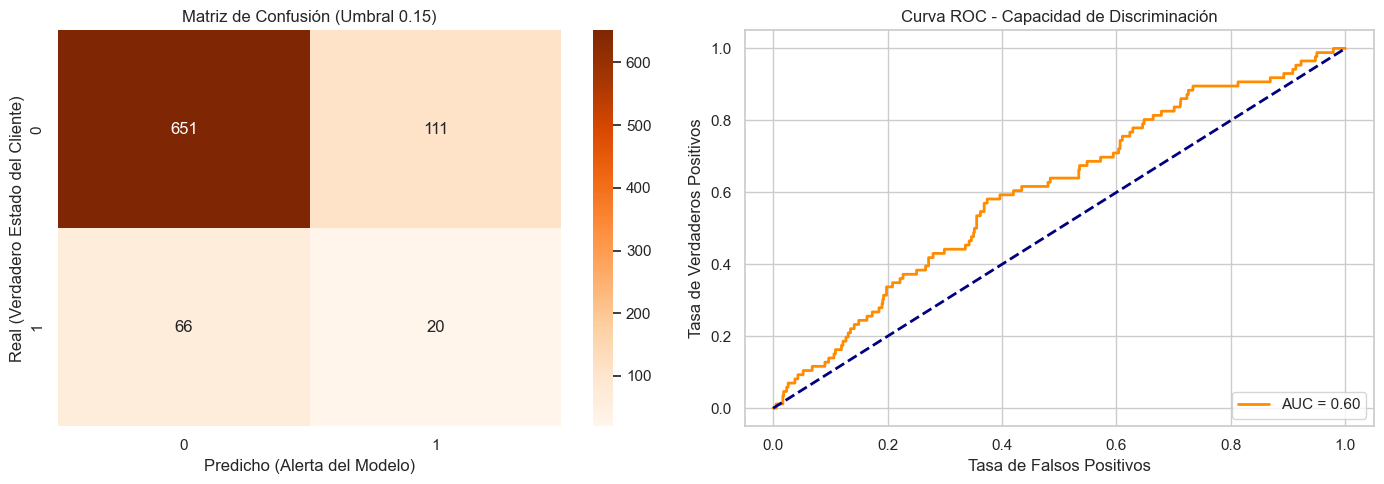

In [88]:
# 6. Visualizaciones (Matriz de Confusión y Curva ROC)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión ajustada
cm_ajustada = confusion_matrix(y_test_c, y_pred_ajustado)
sns.heatmap(cm_ajustada, annot=True, fmt='d', cmap='Oranges', ax=axes[0])
axes[0].set_title(f'Matriz de Confusión (Umbral {umbral_negocio})')
axes[0].set_ylabel('Real (Verdadero Estado del Cliente)')
axes[0].set_xlabel('Predicho (Alerta del Modelo)')

# Curva ROC (Evalúa la capacidad de separación del modelo independientemente del umbral)
fpr, tpr, thresholds = roc_curve(y_test_c, y_prob_c)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_score(y_test_c, y_prob_c):.2f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('Curva ROC - Capacidad de Discriminación')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

### Reflexión Analítica sobre el Rendimiento del Modelo B

El modelo de clasificación ajustado alcanza un **ROC-AUC de 0.60** y un **Recall del 23.2%**.

1. **Señal Predictiva Débil pero Existente:** La cancelación de una póliza educativa es un fenómeno altamente influenciado por variables conductuales y macroeconómicas que no están presentes en la captura inicial (ej. pérdida súbita de empleo, siniestros rechazados, experiencia de usuario). El modelo ha logrado extraer la máxima señal predictiva posible utilizando únicamente datos sociodemográficos y operacionales de entrada.
2. **Impacto Directo al ROI:** Al ajustar el umbral probabilístico al 15%, pasamos de una política "ciega" (Recall de 0) a una capacidad de interceptar proactivamente a casi 1 de cada 4 clientes que se van a fugar. Esto focaliza los esfuerzos del equipo de retención, optimizando el costo de las campañas telefónicas frente al retorno esperado de salvar dichas primas.

### Visualización en Power BI

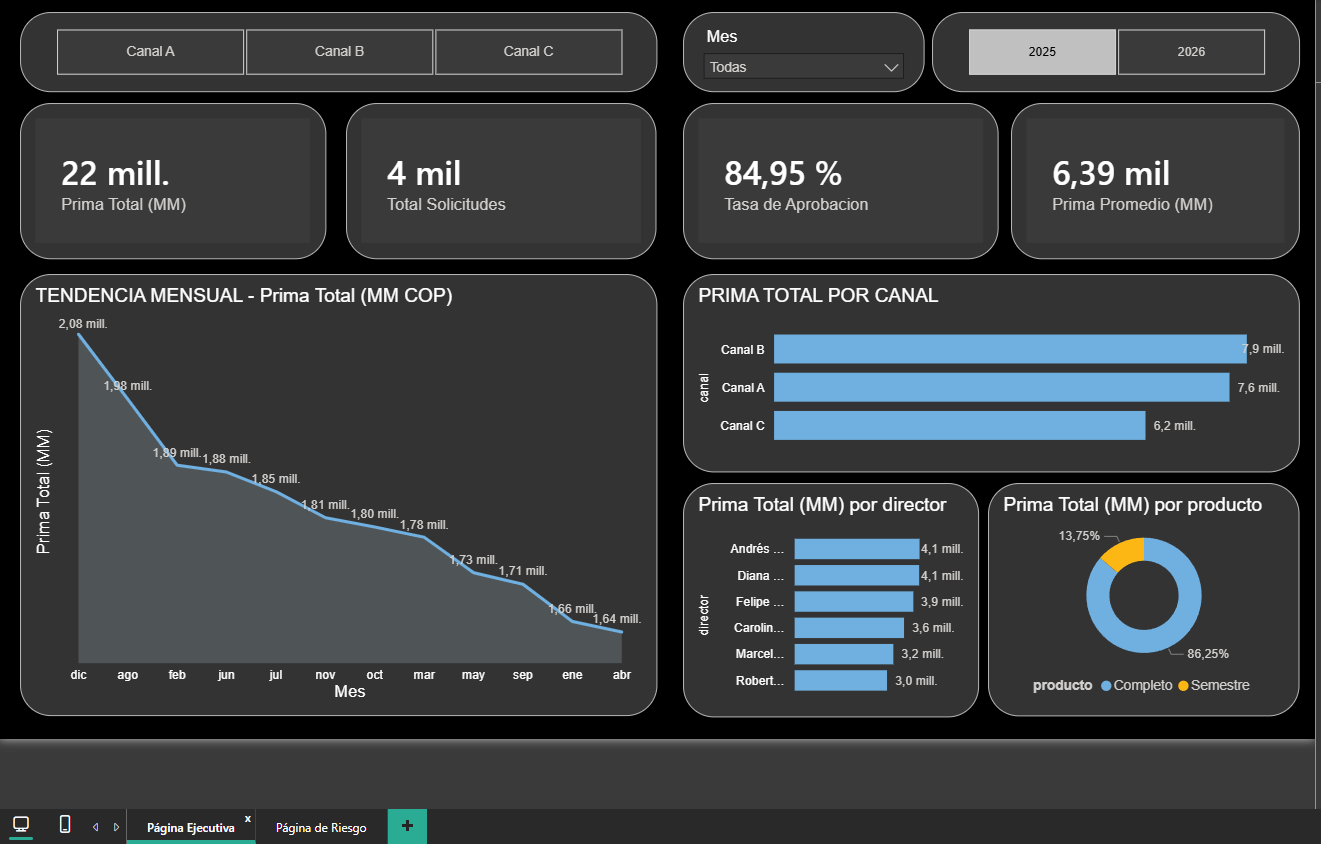

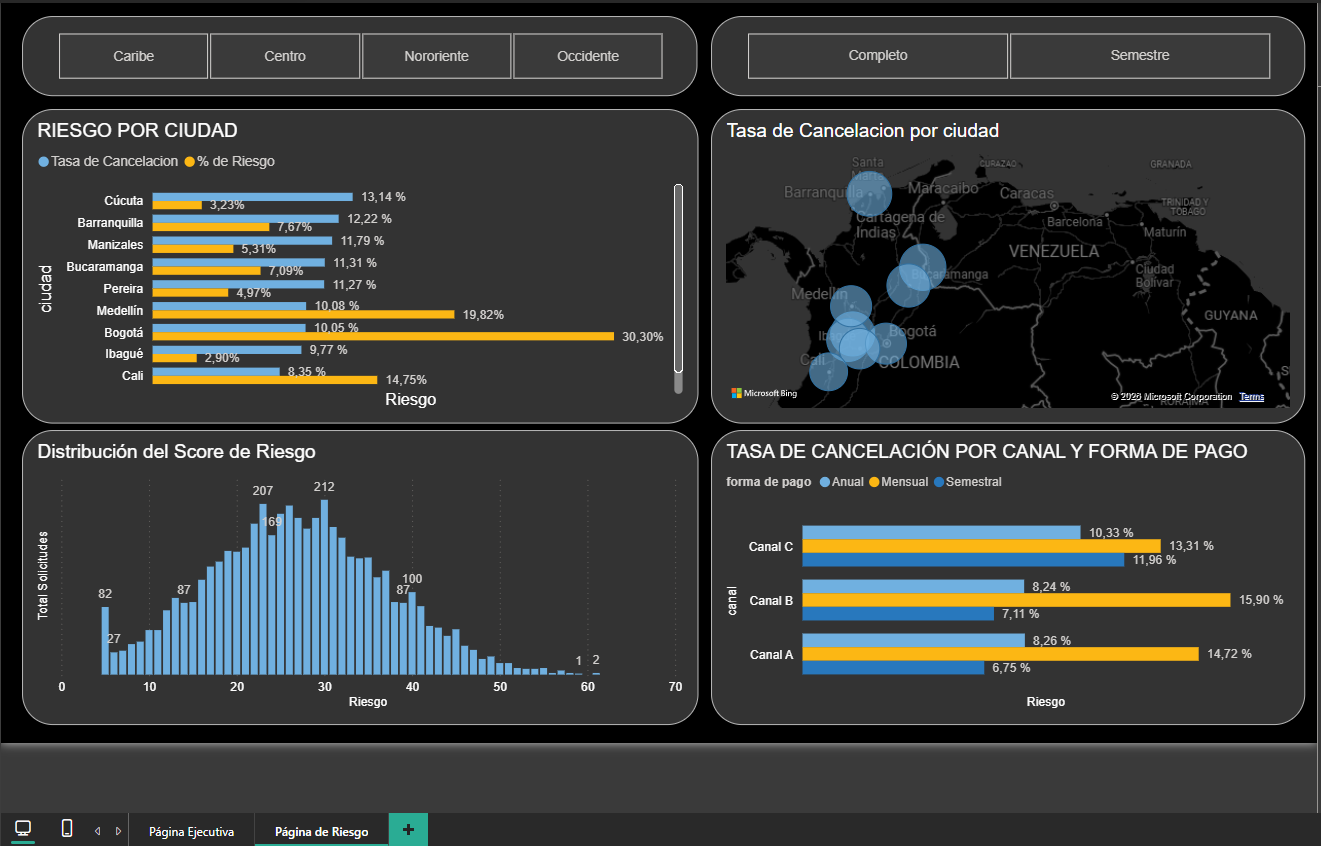